IPL CRICKET ANALYSIS

Load datasets and EDA

In [57]:
import pandas as pd 
import numpy as np

matchdf=pd.read_csv("matches.csv")
delivdf=pd.read_csv("deliveries.csv")
matchdf.head()



,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [58]:
delivdf.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [59]:
matchdf.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

In [60]:
delivdf.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [ ]:
matchdf['umpire3'].value_counts()
matchdf2=matchdf['umpire3'].fillna('Nitin menon')
matchdf2.value_counts()

umpire3
Nitin menon                637
Nitin Menon                 10
C Shamshuddin               10
O Nandan                    10
Anil Chaudhary               9
S Ravi                       8
Vineet Kulkarni              8
Bruce Oxenford               7
Yeshwant Barde               7
Anil Dandekar                7
Chris Gaffaney               6
Rod Tucker                   5
Marais Erasmus               5
Nigel Llong                  4
A Nanda Kishore              3
Nanda Kishore                3
Ian Gould                    3
A.D Deshmukh                 2
Virender Kumar Sharma        2
K Ananthapadmanabhan         2
Ulhas Gandhe                 2
Kumar Dharmasena             2
KN Anantapadmanabhan         1
Sundaram Ravi                1
KN Ananthapadmanabhan        1
Chettithody Shamshuddin      1
Name: count, dtype: int64

In [62]:
matchdf['umpire3']

0                          NaN
1                          NaN
2                          NaN
3                          NaN
4                          NaN
                ...           
751                     S Ravi
752                  Ian Gould
753                        NaN
754    Chettithody Shamshuddin
755                Nigel Llong
Name: umpire3, Length: 756, dtype: object

TASK-1 WHICH TEAM WON/LOSS MAX NUMBER OF MATCHES WHILE CHASING

In [63]:
t11=matchdf[matchdf['winner']==matchdf['team2']]['team2']
t11.groupby(t11).count().idxmax()

'Kolkata Knight Riders'

In [64]:
t12=matchdf[matchdf['winner']!=matchdf['team2']]['team2']
t12.groupby(t12).count().idxmax()

'Delhi Daredevils'

TASK-2 WHICH TOSS DECISION IS BEST FOR EACH VENUE

In [65]:
t2=matchdf.loc[:,['winner','team1','team2','venue']]
t2['bat']=(t2['team1']==t2['winner'])
t2['field']=(t2['team2']==t2['winner'])
t2=t2[['venue','bat','field']]
tt1=pd.DataFrame(t2.groupby('venue')['bat'].apply(lambda x: x[x==True].count()))
tt2=pd.DataFrame(t2.groupby('venue')['field'].apply(lambda x: x[x==True].count()))
t2sol=pd.merge(tt1,tt2,on='venue')
t2sol['decision']=t2sol.apply(lambda row:('bat' if row['bat']>row['field'] else 'equal') if row['bat']>=row['field'] else 'field', axis=1)
t2sol

,bat,field,decision
venue,,,
ACA-VDCA Stadium,0,2,field
Barabati Stadium,4,3,bat
Brabourne Stadium,6,5,bat
Buffalo Park,2,1,bat
De Beers Diamond Oval,1,2,field
Dr DY Patil Sports Academy,7,10,field
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium,6,5,bat
Dubai International Cricket Stadium,3,4,field
Eden Gardens,30,47,field


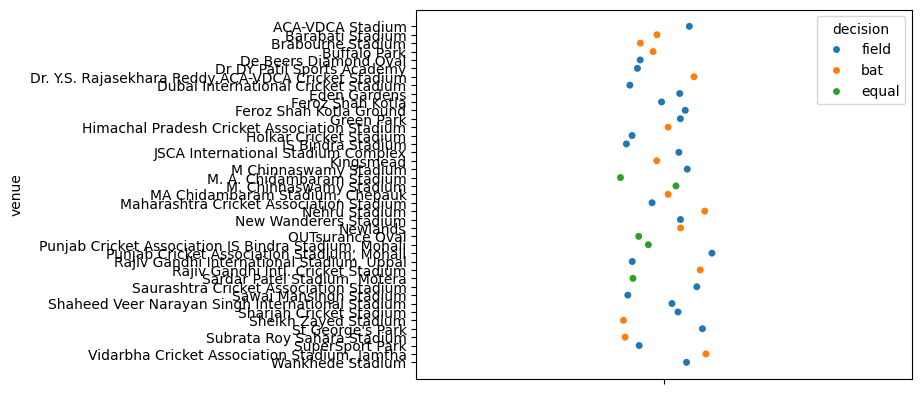

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.stripplot(data=t2sol, y='venue', hue='decision')
plt.show()

TASK-3 WHICH PLAYER HAS WON MAX NUMBER OF PLAYER OF THE MATCH while chasing

In [66]:
t3=matchdf[matchdf['winner']==matchdf['team2']]['player_of_match']
t3.groupby(t3).count().idxmax()



'YK Pathan'

TASK-4 WHICH TEAM WON MAX NUMBER OF MATCHES WHILE CHASING/BATTING FIRST

In [67]:
t4=matchdf.loc[:,['team1','team2','winner','win_by_runs','win_by_wickets']]
t4_chase=t4[t4['winner']==t4['team2']]['winner'].value_counts()
t4_chase.idxmax()

# t4.groupby('winner')['win_by_wickets'].sum().idxmax()
# t4.groupby('winner')['win_by_runs'].sum().idxmax()

'Kolkata Knight Riders'

In [68]:
t4_bat=t4[t4['winner']==t4['team1']]['winner'].value_counts()
t4_bat.idxmax()

'Mumbai Indians'

TASK-5 WHICH BATSMAN HIT MAX NUMBER OF SIXES AND FOURS IN each SEASON

In [69]:
# Use batsman_runs when available, otherwise fall back to total_runs.
runs_col = 'batsman_runs' if 'batsman_runs' in delivdf.columns else 'total_runs'
merged = delivdf.merge(matchdf[['id', 'season']], left_on='match_id', right_on='id', how='left')
merged['is_four'] = merged[runs_col] == 4
merged['is_six'] = merged[runs_col] == 6

season_fours = (
    merged[merged['is_four']]
    .groupby(['season', 'batsman'])
    .size()
    .reset_index(name='fours')
)
season_sixes = (
    merged[merged['is_six']]
    .groupby(['season', 'batsman'])
    .size()
    .reset_index(name='sixes')
)

top_fours = season_fours.loc[season_fours.groupby('season')['fours'].idxmax()].sort_values('season')
top_sixes = season_sixes.loc[season_sixes.groupby('season')['sixes'].idxmax()].sort_values('season')

top_fours, top_sixes

(      season       batsman  fours
 28      2008     G Gambhir     68
 176     2009     ML Hayden     60
 334     2010  SR Tendulkar     86
 464     2011  SR Tendulkar     67
 500     2012     AM Rahane     73
 683     2013    MEK Hussey     81
 814     2014    RV Uthappa     74
 856     2015     DA Warner     65
 956     2016     DA Warner     88
 1070    2017     DA Warner     63
 1226    2018       RR Pant     70
 1332    2019      S Dhawan     65,
       season        batsman  sixes
 80      2008  ST Jayasuriya     31
 102     2009   AC Gilchrist     29
 245     2010     RV Uthappa     27
 286     2011       CH Gayle     44
 388     2012       CH Gayle     59
 486     2013       CH Gayle     52
 591     2014     GJ Maxwell     36
 661     2015       CH Gayle     38
 829     2016        V Kohli     38
 856     2017      DA Warner     26
 997     2018        RR Pant     37
 1021    2019     AD Russell     51)

In [70]:
t5=delivdf.loc[:,['batsman','total_runs']]
t5_four=t5[t5['total_runs']==4]['batsman'].value_counts()
t5_four.idxmax()

'S Dhawan'

TASK-6 MOST WICKETS IN IPL FROM 2008-2018

In [71]:
wicket_df = delivdf[delivdf['player_dismissed'].notna()].copy()
wicket_df = wicket_df[wicket_df['dismissal_kind'].fillna('') != 'run out']
bowler_wickets = wicket_df.groupby('bowler').size().sort_values(ascending=False)
bowler_wickets.head(10).to_dict()
'TOP_BOWLER', bowler_wickets.index[0], int(bowler_wickets.iloc[0])


('TOP_BOWLER', 'SL Malinga', 170)

In [72]:
wicket_df = delivdf[delivdf['player_dismissed'].notna()].copy()
wicket_df = wicket_df[wicket_df['dismissal_kind'].fillna('') != 'run out']
bowler_wickets = wicket_df['bowler'].value_counts()
bowler_wickets.idxmax()

'SL Malinga'

TASK-7 WHICH BATSMAN HAS PLAYED MAX NUMBER OF DOT BALLS  

In [73]:
dot_ball=delivdf[delivdf['total_runs']==0]['batsman'].value_counts()
dot_ball.idxmax()

'V Kohli'

TASK-8 WHICH BATSMAN GOT BOWLED MAX NO OF TIME

In [74]:
a=delivdf[delivdf['dismissal_kind']=='bowled']['player_dismissed'].value_counts()
a.idxmax()

'SR Watson'

TASK-9 WHICH BOWLER BOWL MAX NO OF DOT BALLS

In [75]:
t=delivdf[delivdf['total_runs']==0]['bowler'].value_counts()
t.idxmax()

'Harbhajan Singh'

TASK-10 MOST CENTURIES

In [76]:
centuries=delivdf[delivdf['batsman_runs']>=100]['batsman'].value_counts()
centuries = (
    delivdf.groupby(['match_id', 'batsman'])['batsman_runs']
    .sum()
    .reset_index(name='match_runs')
)
centuries = centuries[centuries['match_runs'] >= 100]['batsman'].value_counts()
if centuries.empty:
    None
else:
    centuries.idxmax()

centuries[0:1]

batsman
CH Gayle    7
Name: count, dtype: int64

TASK-11 HIGEST SCORE IN IPL

In [77]:
higest_score = delivdf.groupby(['match_id', 'batsman'])['batsman_runs'].sum().reset_index(name='total_runs')
higest_score = higest_score.sort_values('total_runs', ascending=False).head(1)
higest_score[['batsman', 'total_runs']].iloc[0] 

batsman       CH Gayle
total_runs         175
Name: 6200, dtype: object

TASK-12 WHICH FIELDER TOOK MOST CATCHES

In [78]:
t12=delivdf[delivdf['dismissal_kind']=='caught']['fielder'].value_counts()
t12.idxmax()

'KD Karthik'

TASK-13 WHICH UMPIRE OFFICIATED THE MOST

In [ ]:
t13=matchdf[['umpire1','umpire2','umpire3']].stack().value_counts()
t13.idxmax()

'S Ravi'